# Setup

In [1]:
import pandas as pd
import numpy as np
import torch
import src
from src.template_generation import *
from src.uid import *
from src.unigram import UnigramLM
import seaborn as sns
import matplotlib.pyplot as plt
from itertools import permutations
import nltk
nltk.download("names")
from nltk.corpus import names

[nltk_data] Downloading package names to /Users/tzhang04/nltk_data...
[nltk_data]   Package names is already up-to-date!
/Users/tzhang04/Desktop/active-passive-alternations/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/tzhang04/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
2026-09-11 13:53:19 INFO: Checking for updates to resources.json in case models have been updated.  Note: this behavior can be turned off with download_method=None or download_method=DownloadMethod.REUSE_RESOURCES
2026-09-11 13:53:19 INFO: Downloaded file to /Users/tzhang04/stanza_resources/resources.json
2026-09-11 13:53:20 INFO: Loading these models for language: en (English):
| Processor | Package           |
------------------------------

In [2]:
# Load model
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")  # metal for mac
else:
    device = torch.device("cpu")
print(f"Loading model on {device}...", end="")
tokenizer, model, _ = load_lm(model_name='distilgpt2', device=device)

Loading model on mps...

Loading weights: 100%|██████████| 76/76 [00:00<00:00, 1185.63it/s, Materializing param=transformer.wte.weight]            
GPT2LMHeadModel LOAD REPORT from: distilgpt2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
transformer.h.{0, 1, 2, 3, 4, 5}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


# Experiments

## Load Templates

In [3]:
# with open("./data/templates/active_templates.txt", "r") as f:
#     active_templates = f.readlines()
# with open("./data/templates/passive_templates.txt", "r") as f:
#     passive_templates = f.readlines()

# templates = pd.DataFrame({
#     "sent_id": range(len(passive_templates)),
#     "passive_template": [temp.strip() for temp in passive_templates],
#     "active_template": [temp.strip() for temp in active_templates]
# })
templates = pd.read_csv("./data/templates/coherent_discourse_pairs_500.csv")

In [4]:
templates.head()

,pair_id,source_domain,lexical_tier,analysis_set,salience_design,primary_analysis,norming_status,coherence_relation,active,passive
0,flv_001,arts_culture,common,core,balanced_shared_predicate,yes,not_normed,shared_preparation,"Before the portrait session, <PRE> and <CTL> r...","Before the portrait session, <PRE> and <CTL> r..."
1,flv_002,arts_culture,common,salience_challenge,ctl_last_separate_predicates,no,not_normed,shared_preparation,"Before a drop-in portrait exercise, <PRE> sele...","Before a drop-in portrait exercise, <PRE> sele..."
2,flv_003,arts_culture,common,core,balanced_shared_predicate,yes,not_normed,shared_goal,"With the final rehearsal approaching, <PRE> an...","With the final rehearsal approaching, <PRE> an..."
3,flv_004,arts_culture,common,core,balanced_shared_predicate,yes,not_normed,shared_followup_need,<PRE> and <CTL> reviewed the gallery talk's un...,<PRE> and <CTL> reviewed the gallery talk's un...
4,flv_005,arts_culture,common,core,balanced_shared_predicate,yes,not_normed,shared_trigger,<PRE> and <CTL> checked the chamber recital's ...,<PRE> and <CTL> checked the chamber recital's ...


## Generate Data

In [5]:
variants = []
names_list = names.words("female.txt") + names.words("male.txt")
np.random.seed(3)
names_sample = np.random.choice(names_list, size=4)
print(names_sample)
variants = generate_data(templates, names_sample)
for sent in np.random.choice(variants['text'], 10):
    print(sent)

['Gilles' 'Eugine' 'Marie' 'Estell']
Eugine and Gilles practiced different halves of a revised movement sequence before the coordinator asked them to combine it without another demonstration. Estell was carefully coached by Marie through the rehearsal.
Gilles and Eugine watched the instructor present a new gesture set before paired gesture practice began. Gilles accurately imitated Marie during the gesture drill.
Marie inspected one posted detour notice for the flooded underpass, while Eugine inspected another posted detour notice for the flooded underpass. Gilles safely led Estell around the flooded underpass.
Eugine and Gilles drew sealed passes assigning one route guide and one guest for a distant roped-off festival section. Marie promptly escorted Estell to the reserved viewing area.
Gilles and Estell unpacked identical assembly kits before the workshop moved into its first paired construction exercise. Gilles was readily helped by Marie with the assembly exercise.
Estell and Marie

In [7]:
variants = variants.merge(templates.drop(columns=['passive', 'active']), on='pair_id', how='left')

In [8]:
[tokenizer(name) for name in names_sample]

[{'input_ids': [38, 21718], 'attention_mask': [1, 1]},
 {'input_ids': [36, 1018, 500], 'attention_mask': [1, 1, 1]},
 {'input_ids': [44507], 'attention_mask': [1]},
 {'input_ids': [22362, 695], 'attention_mask': [1, 1]}]

In [9]:
variants.head()

,patient,agent,control,passive,subject,object,given,text,pair_id,source_domain,lexical_tier,analysis_set,salience_design,primary_analysis,norming_status,coherence_relation
0,Eugine,Gilles,"(Marie, Estell)",True,Eugine,Gilles,Gilles,"Before the portrait session, Gilles and Estell...",flv_001,arts_culture,common,core,balanced_shared_predicate,yes,not_normed,shared_preparation
1,Eugine,Gilles,"(Marie, Estell)",True,Eugine,Gilles,Eugine,"Before the portrait session, Eugine and Estell...",flv_001,arts_culture,common,core,balanced_shared_predicate,yes,not_normed,shared_preparation
2,Eugine,Gilles,"(Marie, Estell)",True,Eugine,Gilles,Marie,"Before the portrait session, Marie and Estell ...",flv_001,arts_culture,common,core,balanced_shared_predicate,yes,not_normed,shared_preparation
3,Eugine,Gilles,"(Marie, Estell)",False,Gilles,Eugine,Gilles,"Before the portrait session, Gilles and Estell...",flv_001,arts_culture,common,core,balanced_shared_predicate,yes,not_normed,shared_preparation
4,Eugine,Gilles,"(Marie, Estell)",False,Gilles,Eugine,Eugine,"Before the portrait session, Eugine and Estell...",flv_001,arts_culture,common,core,balanced_shared_predicate,yes,not_normed,shared_preparation


In [10]:
variants.iloc[0]

patient                                                          Eugine
agent                                                            Gilles
control                                                 (Marie, Estell)
passive                                                            True
subject                                                          Eugine
object                                                           Gilles
given                                                            Gilles
text                  Before the portrait session, Gilles and Estell...
pair_id                                                         flv_001
source_domain                                              arts_culture
lexical_tier                                                     common
analysis_set                                                       core
salience_design                               balanced_shared_predicate
primary_analysis                                                

## Compute Surprisals

In [ ]:
process_results(model, tokenizer, device, variants)

Token indices sequence length is longer than the specified maximum sequence length for this model (2504304 > 1024). Running this sequence through the model will result in indexing errors
  0%|          | 4/72000 [00:10<54:12:35,  2.71s/it] 


KeyboardInterrupt: 

In [ ]:
# uid_results = pd.DataFrame(uid_results)
uid_results.shape, uid_results.columns

((46, 26),
 Index(['raw_surps', 'surp_mean', 'surp_slor', 'uid_std', 'uid_mad', 'uid_pwd',
        'uid_range', 'uid_cv', 'uid_slope', 'uid_len', 'units', 'context',
        'sentence', 'patient', 'agent', 'control', 'passive', 'subject',
        'object', 'given', 'text', 'sent_id', 'given_first', 'given_last',
        'given_pos', 'context_type'],
       dtype='str'))

# Analysis

List of questions to answer:
1. Are given-first orderings more or less uniform?
    - Test pairwise differences against given-first vs. given-last, between passive vs. active
2. Are surprisals at the given constituent lower or higher than the non-given?
3. Does including discourse context (preamble) enhance the difference?

** Check that Surp STD contains the first word 

## Data Cleaning

In [4]:
uid_results = pd.read_csv("temp_results.csv")

In [ ]:
uid_results["given_first"] = uid_results["given"] == uid_results["subject"]
uid_results["given_last"] = uid_results["given"] == uid_results["object"]
uid_results["given_pos"] = ["f" if uid_results["given_first"].iloc[i] 
                                else "l" if uid_results['given_last'].iloc[i] 
                                else "c"
                              for i in range(uid_results.shape[0])]
uid_results["has_context"] = uid_results["context"].notna()
uid_results["control"] = uid_results["control"].apply(lambda x: eval(x) if isinstance(x, str) else x)
uid_results["control1"] = uid_results["control"].str[0]
uid_results["control2"] = uid_results["control"].str[1]
uid_results["sent_id"] = uid_results["pair_id"] + uid_results["passive"]
uid_results.head(3)

TypeError: can only concatenate str (not "bool") to str

In [6]:
uid_results.iloc[2]['sentence']

'Eugine was carefully photographed by Gilles against a plain linen backdrop.'

## Q1: GF vs. GL vs. Ctl

Overall Distributions

In [7]:
uid_results.groupby(['passive', 'given_pos'])[["surp_slor", "uid_std", "uid_pwd"]].mean()

surp_slor   uid_std     uid_pwd
passive given_pos                                 
False   c          -4.923215  8.236865  100.399235
        f          -3.884708  6.712502   84.340005
        l          -4.331694  8.076793   86.551086
True    c          -3.300153  7.956040  141.280445
        f          -2.495045  6.623200  114.016861
        l          -2.824687  7.735266  126.217818

Text(0.5, 0.98, 'UID Metric Distributions')

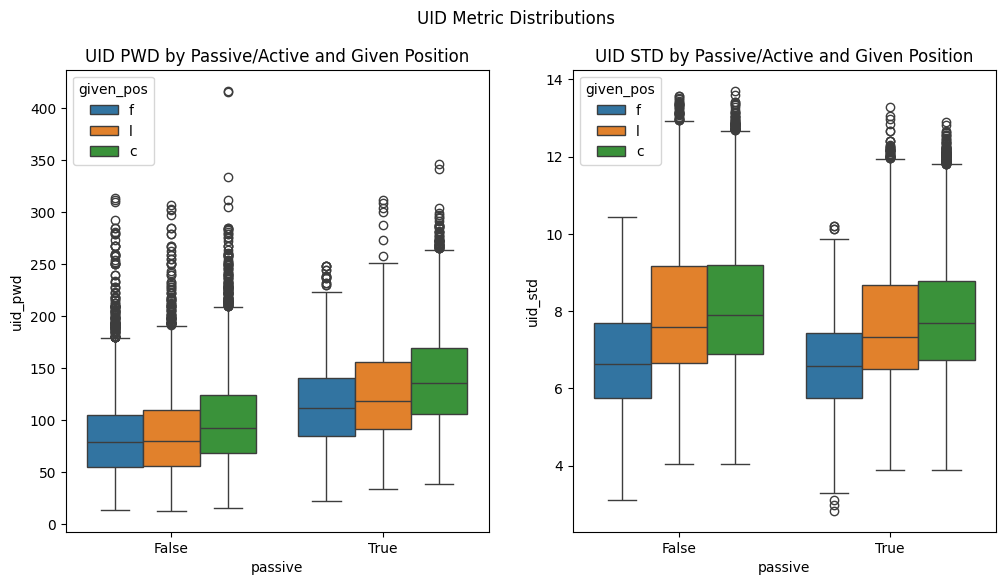

In [8]:
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
sns.boxplot(data=uid_results, x='passive', y='uid_pwd', hue='given_pos', ax=axs[0])
axs[0].set_title("UID PWD by Passive/Active and Given Position")
sns.boxplot(data=uid_results, x='passive', y='uid_std', hue='given_pos', ax=axs[1])
axs[1].set_title("UID STD by Passive/Active and Given Position")
fig.suptitle("UID Metric Distributions")

Pairwise Differences

Sentence pairs should have the same subject, object, given names, and given position. This will be passive - active.

In [9]:
uid_results.columns

Index(['raw_surps', 'surp_mean', 'surp_slor', 'uid_std', 'uid_mad', 'uid_pwd',
       'uid_range', 'uid_cv', 'uid_slope', 'uid_len', 'units', 'context',
       'sentence', 'patient', 'agent', 'control', 'passive', 'subject',
       'object', 'given', 'text', 'pair_id', 'given_first', 'given_last',
       'given_pos', 'has_context', 'control1', 'control2'],
      dtype='str')

In [ ]:
get_diff = lambda s: s.diff().iloc[1]
mapping = {
    "uid_std": get_diff,
    "uid_pwd": get_diff,
    "text": lambda s: list(s),
    "sentence": lambda s: list(s),
    "context": lambda s: list(s),
    "units": lambda s: list(s),
    "given_pos": lambda s: " to ".join(s)
}
uid_results_diff = (uid_results[(uid_results['given_pos'] != 'c') & (uid_results['has_context'])]
                    .groupby(
                        ["sent_id", "control2", "control1", "given", "patient", "agent"]
                    )[["uid_std", "uid_pwd", "text", "given_pos", "sentence", "context", "units"]]
                    .agg(mapping).reset_index())
uid_results_diff = uid_results_diff[uid_results_diff['given_pos'].isin(["f to l", "l to f"])]
uid_results_diff.head(10) # active - passive


IndexError: single positional indexer is out-of-bounds

In [11]:
uid_results_diff['text'].iloc[500]

NameError: name 'uid_results_diff' is not defined

In [12]:
uid_results_diff['given_pos'].value_counts()

NameError: name 'uid_results_diff' is not defined

NameError: name 'uid_results_diff' is not defined

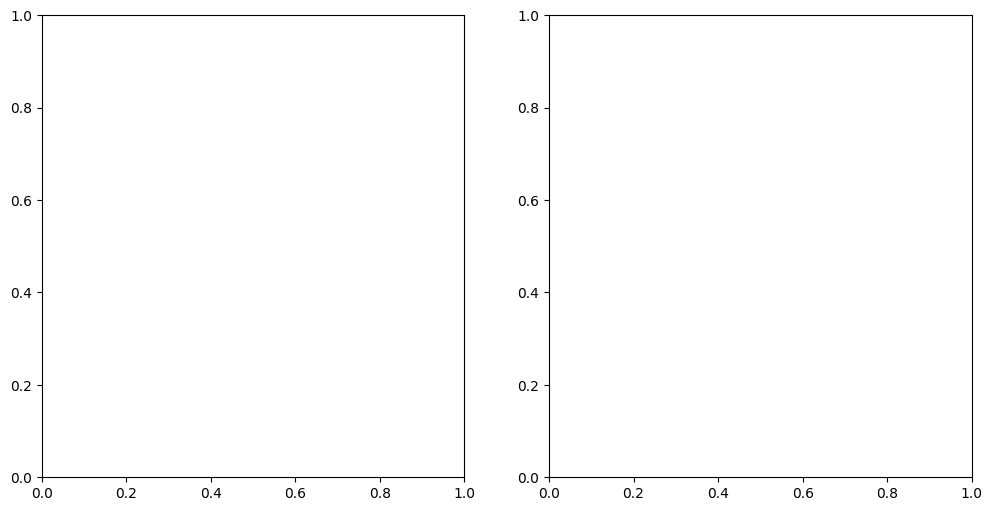

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
sns.boxplot(data=uid_results_diff, x='given_pos', y='uid_std', showfliers=False, ax=ax[0])
ax[0].axhline(y=0, color='r', linestyle='--')
ax[0].set_title("UID STD Active - Passive")
sns.boxplot(data=uid_results_diff, x='given_pos', y='uid_pwd', showfliers=False, ax=ax[1])
ax[1].axhline(y=0, color='r', linestyle='--')
ax[1].set_title("UID PWD Active - Passive")

In [14]:
sentence = variants_full.iloc[0]
surprisals = sentence['raw_surps']
units1 = [s.strip('Ġ') for s in sentence['units']]
sns.lineplot(x=range(len(surprisals)), y=surprisals, marker='o', label=sentence['given_pos'])

sentence = variants_full.iloc[1]
surprisals = sentence['raw_surps']
units2 = [s.strip('Ġ') for s in sentence['units']]
sns.lineplot(x=range(len(surprisals)), y=surprisals, marker='o', label=sentence['given_pos'])

plt.xticks(ticks=range(len(surprisals)), 
           labels=[f"{unit1}:{unit2}" if unit1 != unit2 else unit1 for unit1, unit2 in zip(units1, units2)], 
           rotation=90)

NameError: name 'variants_full' is not defined